# Модуль 8. Алгоритмы и структуры данных
## Практика по линейному и бинарному поиску

### **Задача 1**

Дан список `list1`, содержащий целые числа, часть из которых чётные. Вам нужно их найти.

Рассматривайте эту задачу как вариацию линейного поиска. Но ищете вы не одно число, а несколько — те, которые удовлетворяют определённому критерию (чётности).

Напишите код, который находит в списке все чётные числа и собирает их в другой список — `evens`. Напечатайте список `evens` на экране.

_Подсказка_

Результат любого деления — это `частное` и `остаток`. Если одно число делится на другое нацело, то остаток равен нулю. Например, `4 = 2 * 2 + 0`, значит, если `4` разделить на `2`, то `2` будет частным, а `0` — остатком. А если числа не делятся нацело, то остаток, соответственно, ненулевой: `5 = 2 * 2 + 1`, и при делении `5` на `2` частное — это `2`, а остаток — `1`.

Получается, число будет чётным, только когда остаток от деления этого числа на `2` равен `0`.

В Python есть специальная операция, с помощью которой можно получить остаток от деления. Эта операция — `%`. Например, `4 % 2 = 0`, а `5 % 2 = 1`.

Теперь вы знаете, как определить, что число является чётным.

**Решение:** поскольку нам нужно найти несколько чисел, для их хранения мы создадим дополнительный список и назовём его `evens` («Чётные»).

In [ ]:
list1 = [1, 12, 5, 7, 9, 18, 16, 0, 3, 13, 8, 91, 72]
evens = []

Обойдём все индексы элементов списка, построив цикл for по длине списка. Внутри цикла будем проверять очередной элемент на чётность с помощью остатка от деления на 2: если остаток равен нулю, то элемент чётный (делится на 2 без остатка), значит, добавляем его в список чётных.

In [ ]:
for elem_index in range(len(list1)):
    if list1[elem_index] % 2 == 0:
        evens.append(list1[elem_index])

print(evens)

[12, 18, 16, 0, 8, 72]


---

### **Задача 2**

В этом задании вы будете экспериментально исследовать поведение алгоритма линейного поиска. В ячейке ниже объявлен список списков (_с таким вы уже встречались_) разной длины. Не обращайте внимания на сложную конструкцию вида `random.choices(range(0, 1_000_000), k=10)` — здесь использованы ещё не известные вам средства языка, чтобы решить простую задачу: **создать список заданной длины (`k`), состоящий из случайных чисел**.

Под случайными числами нужно понимать следующее: каждый раз, когда вы будете запускать ячейку с кодом, числа будут новыми. Получается, список `list2` содержит десять списков из случайных чисел, все списки разной длины: от 10 до 1 000 000 элементов соответственно. Кроме того, задано число `desired` (тоже случайное).

Ваша задача:
1. Для каждого списка из `lists2` реализуйте алгоритм линейного поиска, ищите число `desired`. Посчитайте для каждого списка количество итераций (переменная `iterations`), которое потребовалось, чтобы завершить алгоритм поиска.
2. Каждый раз, когда завершается очередной поиск, печатайте на экране длину списка, в котором искали, и число итераций, которое сделали.
3. Позицию найденного числа (если оно нашлось) печатать не нужно — просто прерывайте цикл инструкцией `break`.

Задача исследовательская — собрать данные о зависимости числа итераций алгоритма от размера входных данных (размера списка).

**Решение:** шаблон кода уже дан, в нём строится цикл по спискам из `lists2`. На каждой итерации цикла берётся очередной список, а число итераций обнуляется.

Задача — дописать линейный поиск для каждого из списков в списке `lists2`, то есть для списка `current_list`.

Алгоритм линейного поиска прост: в цикле проверяем каждый элемент в списке на равенство искомому. Если равен — завершаем цикл поиска. Число итераций линейного поиска — это количество всех итераций до тех пор, пока элемент не будет найден, поэтому увеличиваем счётчик на единицу каждую итерацию внутреннего цикла.

In [ ]:
import random

desired = random.randint(0, 1_000_000)

lists2 = [
    random.choices(range(0, 1_000_000), k=10),
    random.choices(range(0, 1_000_000), k=100),
    random.choices(range(0, 1_000_000), k=500),
    random.choices(range(0, 1_000_000), k=1000),
    random.choices(range(0, 1_000_000), k=5000),
    random.choices(range(0, 1_000_000), k=10_000),
    random.choices(range(0, 1_000_000), k=50_000),
    random.choices(range(0, 1_000_000), k=100_000),
    random.choices(range(0, 1_000_000), k=500_000),
    random.choices(range(0, 1_000_000), k=1_000_000),
]

for i in range(len(lists2)):
    current_list = lists2[i]
    iterations = 0

    for elem_index in range(len(current_list)):
        iterations += 1
        if current_list[elem_index] == desired:
            break

    print(len(current_list), iterations)

10 10
100 100
500 500
1000 1000
5000 5000
10000 10000
50000 50000
100000 100000
500000 500000
1000000 613216


---

### **Задача 3**

Эта задача похожа на предыдущую: вам снова предстоит считать число итераций алгоритма на списках разной длины, но уже для бинарного поиска.

У вас снова есть список списков из случайных чисел, но теперь они отсортированы (обратите внимание на функцию `sorted`). Реализуйте для каждого бинарный поиск (ищите число `desired`) и печатайте на экране размер списка и число затраченных итераций. Позицию найденного числа (если оно найдётся) выводить не нужно.

**Решение:** шаблон кода уже дан, в нём строится цикл по спискам из `lists2`. На каждой итерации цикла берётся очередной список, а число итераций обнуляется.

Задача — дописать бинарный поиск для каждого из списков в списке `lists2`, то есть для списка `current_list`.

Алгоритм бинарного поиска чуть труднее, чем алгоритм линейного поиска, но тоже несложный. Вспомните: достаточно просто искать число либо в правой, либо в левой половине списка, в зависимости от того, больше искомый элемент, чем половина, или нет. Соответственно, цикл будет продолжаться до тех пор, пока левая граница меньше правой (пока они не сошлись в одно значение).

Для реализации нужно определить границы (левый и правый индексы отрезка, в котором осуществляется поиск, то есть переменные left и right). Изначально мы ищем во всём списке, поэтому определяем их как `0` и `len(current_list) - 1`.

Каждую итерацию цикла поиска мы ищем середину списка — полусумму границ `left` и `right`, то есть `middle = (left + right) // 2`.

Остаётся сравнить искомый элемент и полученную середину: если элемент больше, чем число, находящееся посередине, поиск продолжается в правой половине списка (`left = middle + 1`), если меньше — в левой (`right = middle - 1`).

Число итераций бинарного поиска — количество всех итераций до тех пор, пока элемент не будет найден, поэтому увеличиваем счётчик на единицу каждую итерацию внутреннего цикла.

In [ ]:
import random

desired = random.randint(0, 1_000_000)

lists3 = [
    sorted(random.choices(range(0, 1_000_000), k=10)),
    sorted(random.choices(range(0, 1_000_000), k=100)),
    sorted(random.choices(range(0, 1_000_000), k=500)),
    sorted(random.choices(range(0, 1_000_000), k=1000)),
    sorted(random.choices(range(0, 1_000_000), k=5000)),
    sorted(random.choices(range(0, 1_000_000), k=10_000)),
    sorted(random.choices(range(0, 1_000_000), k=50_000)),
    sorted(random.choices(range(0, 1_000_000), k=100_000)),
    sorted(random.choices(range(0, 1_000_000), k=500_000)),
    sorted(random.choices(range(0, 1_000_000), k=1_000_000)),
]

for i in range(len(lists3)):
    current_list = lists3[i]

    iterations = 0

    left = 0
    right = len(current_list) - 1
    middle = 0

    while left <= right:
        iterations += 1

        middle = (left + right) // 2

        if desired > current_list[middle]:
            left = middle + 1
        elif desired < current_list[middle]:
            right = middle - 1
        else:
            break

    print(len(current_list), iterations)

10 4
100 6
500 9
1000 10
5000 12
10000 14
50000 16
100000 17
500000 18
1000000 19


---

### **Задача 4**

Вы собрали наблюдения (данные) о зависимости количества итераций алгоритма от размера входных данных для линейного и бинарного поиска. Скопируйте их в Excel-таблицу вида:

| Размер списка | Линейный поиск | Бинарный поиск |
| ----------- | ------------ | ------------ |
| _значение_    | _значение_    | _значение_     |


Нарисуйте график зависимости итераций от размера списка. Используя _обычный_ график (линии), расположите обе зависимости на одном графике: по оси x — размер списка, по оси y — количество итераций.

**Решение:** если вы всё сделали правильно, у вас получилось приблизительно как в нашем примере:

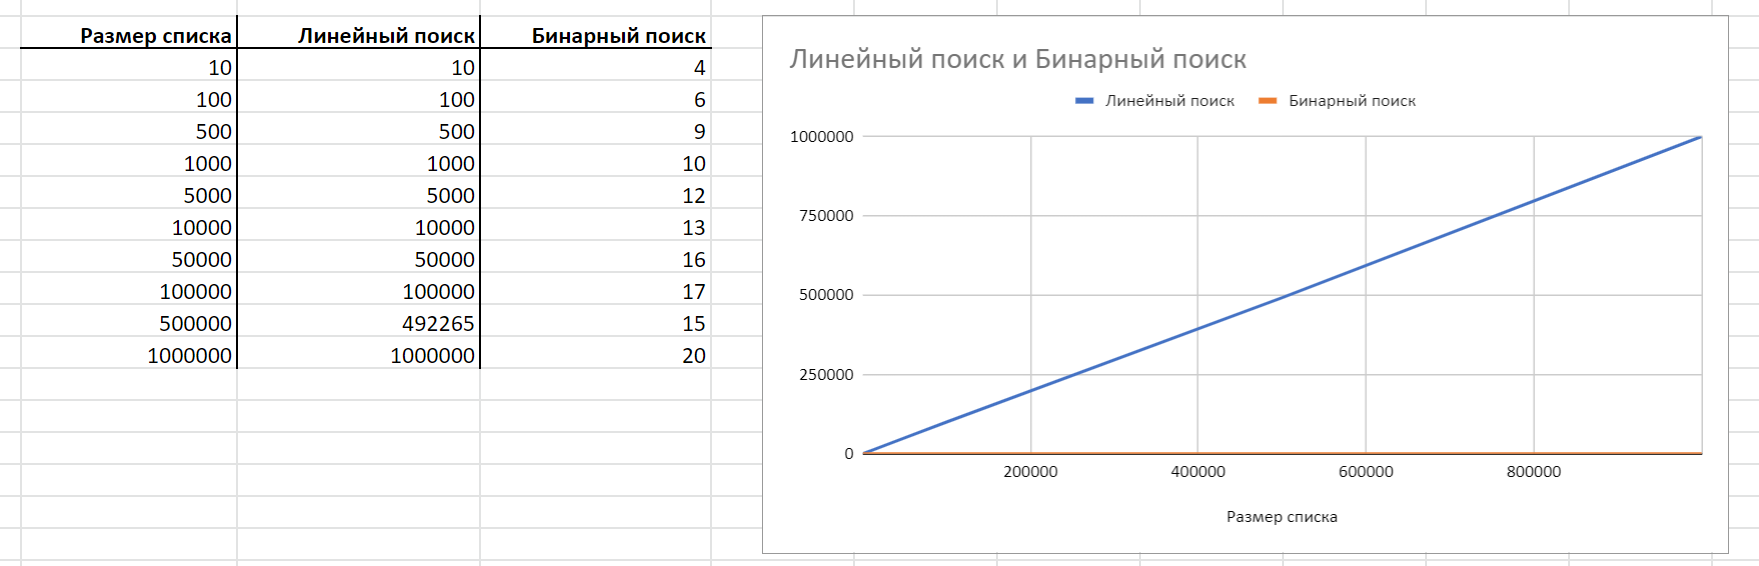

Линия зависимости для линейного поиска неуклонно идёт вверх, и ничто не может её остановить: чем больше элементов в списке, тем дольше работает алгоритм, причём прямо пропорционально. А вот линия бинарного поиска, наоборот, стелется вдоль оси `x`, буквально сливается с ней. Дело в том, что масштаб (на графике) в числе итераций отличается на порядок: для линейного поиска — сотни тысяч и даже миллионы, для бинарного — всё ещё десятки.

В общем, этот график (на данных, полученных в эксперименте) наглядно показывает отличия линейного алгоритма от бинарного. Бинарный **намного** быстрее линейного. Если, конечно, список предварительно отсортирован.